In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


# sklearn
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
db = pd.read_csv('/kaggle/input/datasets/ashik17cse/studentssafe/StudentSafeV2.csv')
print(db.columns)

Index(['Timestamp',
       'Consent Form\nDo you consent to participate in this survey? Your information will be kept confidential and used only for research purposes.',
       'Mobile number (optional)', 'What is your age?', 'What is your gender?',
       'What is your religious identity?',
       'How often you perform your religious activities?',
       'Where do you currently live? (Urban refers to cities or towns; Rural refers to villages or countryside) ',
       'What is your marital status?',
       'Do you have any source of income? (Do you earn money from any source?)',
       'What is your education level?',
       'What is your Institutions? \nPlease select Others if the institution is not in the list and specify manually.',
       'If you have selected Others, then specify your institution's name.',
       'What is your current CGPA up to previous semester or year out of 4.00? Please write in numeric form, for example 3.45.\nMedical Students write pass or fail  instead of 

In [3]:
db

,Timestamp,Consent Form\nDo you consent to participate in this survey? Your information will be kept confidential and used only for research purposes.,Mobile number (optional),What is your age?,What is your gender?,What is your religious identity?,How often you perform your religious activities?,Where do you currently live? (Urban refers to cities or towns; Rural refers to villages or countryside),What is your marital status?,Do you have any source of income? (Do you earn money from any source?),...,What is your father's highest level of education? (Primary: Class 0-5; Secondary: Class 6-12 or Diploma; Higher education: Bachelor's degree or above,What is your father's occupation?,What is your mother's highest level of education? (Primary: Class 0-5; Secondary: Class 6-12 or Diploma; Higher education: Bachelor's degree or above),What is your mother's occupation?,"How often do you use psychoactive substances? (Substances that affect your mind or mental processes, such as drugs, alcohol, etc.)",How often do you smoke cigarettes?,"How often do you experience anxiety? (Feeling nervous, worried, or uneasy about what might happen)",How often do you experience insomnia (a common sleep disorder that can make it hard to fall asleep or stay asleep )?,"How often do you use electronic devices (laptop, desktop, smartphones, etc.)?",Have you ever thought about taking your own life or Have you ever wanted to end your life?
0,5/19/2025 13:58,Yes,NaN,NaN,Male,Muslim,NaN,Urban,Married,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5/20/2025 9:36,Yes,NaN,27.0,Male,Muslim,Regularly,Urban,Married,Yes,...,Secondary,Businessman,Secondary,Service Holder,Never,Never,Often,Often,Regular,Never
2,5/21/2025 22:33,Yes,1767275257,27.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,...,Secondary,Agricultural Worker/Farmer,Primary,Homemaker,Never,Never,Often,Often,Regular,Attempted once or more
3,5/21/2025 22:37,Yes,1609098450,26.0,Male,Muslim,Often,Urban,Unmarried,Yes,...,Primary,Service Holder,Primary,Homemaker,Never,Never,Often,Often,Regular,Never
4,5/21/2025 22:51,Yes,1737408519,26.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,...,Secondary,Businessman,Primary,Homemaker,Regular,Never,Often,Never,Regular,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,8/24/2025 9:08,Yes,NaN,29.0,Male,Muslim,Rarely,Urban,Unmarried,No,...,Secondary,Service Holder,Secondary,Service Holder,Often,Never,Often,Never,Often,Thought but no plan
4000,8/24/2025 9:09,Yes,NaN,27.0,Famale,Non-Muslim,Rarely,Urban,Married,No,...,Secondary,Businessman,Higher education,Service Holder,Often,Often,Often,Never,Often,Never
4001,8/24/2025 9:10,Yes,NaN,29.0,Male,Non-Muslim,Often,Rural,Married,Yes,...,Secondary,Service Holder,Primary,Service Holder,Often,Often,Often,Often,Often,Planned but not attempted
4002,8/24/2025 9:10,Yes,NaN,28.0,Male,Muslim,Regularly,Urban,Married,Yes,...,Secondary,Businessman,Secondary,Homemaker,Regular,Often,Never,Often,Regular,Never


In [4]:
db.shape

(4004, 35)

In [5]:
db = db.drop_duplicates()
db

,Timestamp,Consent Form\nDo you consent to participate in this survey? Your information will be kept confidential and used only for research purposes.,Mobile number (optional),What is your age?,What is your gender?,What is your religious identity?,How often you perform your religious activities?,Where do you currently live? (Urban refers to cities or towns; Rural refers to villages or countryside),What is your marital status?,Do you have any source of income? (Do you earn money from any source?),...,What is your father's highest level of education? (Primary: Class 0-5; Secondary: Class 6-12 or Diploma; Higher education: Bachelor's degree or above,What is your father's occupation?,What is your mother's highest level of education? (Primary: Class 0-5; Secondary: Class 6-12 or Diploma; Higher education: Bachelor's degree or above),What is your mother's occupation?,"How often do you use psychoactive substances? (Substances that affect your mind or mental processes, such as drugs, alcohol, etc.)",How often do you smoke cigarettes?,"How often do you experience anxiety? (Feeling nervous, worried, or uneasy about what might happen)",How often do you experience insomnia (a common sleep disorder that can make it hard to fall asleep or stay asleep )?,"How often do you use electronic devices (laptop, desktop, smartphones, etc.)?",Have you ever thought about taking your own life or Have you ever wanted to end your life?
0,5/19/2025 13:58,Yes,NaN,NaN,Male,Muslim,NaN,Urban,Married,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5/20/2025 9:36,Yes,NaN,27.0,Male,Muslim,Regularly,Urban,Married,Yes,...,Secondary,Businessman,Secondary,Service Holder,Never,Never,Often,Often,Regular,Never
2,5/21/2025 22:33,Yes,1767275257,27.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,...,Secondary,Agricultural Worker/Farmer,Primary,Homemaker,Never,Never,Often,Often,Regular,Attempted once or more
3,5/21/2025 22:37,Yes,1609098450,26.0,Male,Muslim,Often,Urban,Unmarried,Yes,...,Primary,Service Holder,Primary,Homemaker,Never,Never,Often,Often,Regular,Never
4,5/21/2025 22:51,Yes,1737408519,26.0,Male,Muslim,Regularly,Urban,Unmarried,Yes,...,Secondary,Businessman,Primary,Homemaker,Regular,Never,Often,Never,Regular,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,8/24/2025 9:08,Yes,NaN,29.0,Male,Muslim,Rarely,Urban,Unmarried,No,...,Secondary,Service Holder,Secondary,Service Holder,Often,Never,Often,Never,Often,Thought but no plan
4000,8/24/2025 9:09,Yes,NaN,27.0,Famale,Non-Muslim,Rarely,Urban,Married,No,...,Secondary,Businessman,Higher education,Service Holder,Often,Often,Often,Never,Often,Never
4001,8/24/2025 9:10,Yes,NaN,29.0,Male,Non-Muslim,Often,Rural,Married,Yes,...,Secondary,Service Holder,Primary,Service Holder,Often,Often,Often,Often,Often,Planned but not attempted
4002,8/24/2025 9:10,Yes,NaN,28.0,Male,Muslim,Regularly,Urban,Married,Yes,...,Secondary,Businessman,Secondary,Homemaker,Regular,Often,Never,Often,Regular,Never


In [6]:
db.shape

(4003, 35)

In [7]:
#making the column questions to short name columns
new_columns = [
    'timestamp', 'consent', 'mobile_no', 'age', 'gender', 'religion',
    'religious_activity', 'residence', 'marital_status', 'has_income',
    'education_level', 'institution', 'institution_other', 'cgpa',
    'institution_type', 'field_of_study', 'year_of_study', 'class_participation',
    'uni_satisfaction', 'academic_gap', 'session_jam', 'ragging',
    'career_depression', 'family_type', 'family_environment', 'father_education',
    'father_occupation', 'mother_education', 'mother_occupation', 'substance_use',
    'smoking', 'anxiety', 'insomnia', 'device_usage', 'suicidal_risk'
]

db.columns = new_columns

## Let us Plot in BD MAP

In [8]:
df_test = db

In [9]:
df_test['institution'].value_counts()

institution
National University                              456
Dhaka College                                    406
University of Barishal                           263
Comilla University                               261
Islamic University, Bangladesh                   229
                                                ... 
Varendra University                                1
University of Liberal Arts Bangladesh              1
University of Asia Pacific                         1
University of Science & Technology Chittagong      1
Northern University Bangladesh                     1
Name: count, Length: 101, dtype: int64

In [10]:
# Get the names as a Pandas Index object
unique_names = df_test['institution'].value_counts().index

# Get the names as a standard Python list
unique_names_list = df_test['institution'].value_counts().index.tolist()
unique_names_list

['National University',
 'Dhaka College',
 'University of Barishal',
 'Comilla University',
 'Islamic University, Bangladesh',
 'Bangladesh Open University',
 'Jagannath University',
 'Dhaka International University',
 'Jahangirnagar University',
 'Chittagong University of Engineering & Technology (CUET)',
 'University of Chittagong',
 'Gazipur Agricultural University',
 'University of Rajshahi',
 'Kurigram Agricultural University',
 'Khulna University',
 'University of Dhaka',
 'Kabi Nazrul Govt. College',
 'Bangladesh Agricultural University',
 'Sher-e-Bangla Agricultural University',
 'Prime Medical College, Rangpur',
 'Dhaka University of Engineering & Technology (DUET)',
 'Mawlana Bhashani Science & Technology University',
 'Jessore University of Science & Technology',
 'Khulna University of Engineering & Technology (KUET)',
 'Hajee Mohammad Danesh Science & Technology University',
 'Pabna University of Science and Technology',
 'Rajshahi University of Engineering & Technology (RU

In [11]:
len(unique_names_list)

101

In [12]:
df_test['institution_name'] = df_test['institution'].str.strip()

/tmp/ipykernel_16/3242149722.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['institution_name'] = df_test['institution'].str.strip()


In [13]:
import pandas as pd

# Example mapping
mapping = {
    "Never": "Risk Negative",
    "Thought but no plan": "Risk Positive",
    "Planned but not attempted": "Risk Positive",
    "Attempted once or more": "Risk Positive"
}

# Apply mapping
df_test['suicidal_risk'] = df_test['suicidal_risk'].map(mapping)

# Verify the counts
print(df_test['suicidal_risk'].value_counts())

# Optional: preview unique labels
print(df_test['suicidal_risk'].unique())


suicidal_risk
Risk Positive    2708
Risk Negative    1294
Name: count, dtype: int64
[nan 'Risk Negative' 'Risk Positive']


/tmp/ipykernel_16/3303790822.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['suicidal_risk'] = df_test['suicidal_risk'].map(mapping)


In [14]:
# Create a frequency table of institutions vs. risk status
risk_summary = pd.crosstab(df_test['institution'], df_test['suicidal_risk'])

print(risk_summary)

suicidal_risk                                    Risk Negative  Risk Positive
institution                                                                  
Ad-din Women's Medical College                               1              0
Ahsanullah University of Science and Technology              0              1
American International University-Bangladesh                 0              3
Asian University of Bangladesh                               0              1
Aviation And Aerospace University, Bangladesh                0              3
...                                                        ...            ...
University of South Asia                                     2              0
Uttara University                                            1              1
Varendra University                                          0              1
World University of Bangladesh                               3              2
Z. H. Sikder Women's Medical College                         1  

In [15]:
# clean institution names first
df_test['institution_name'] = df_test['institution_name'].str.strip()

division_map = {

    # Dhaka Division
    'Dhaka College': 'Dhaka',
    'Jagannath University': 'Dhaka',
    'Dhaka International University': 'Dhaka',
    'Daffodil International University': 'Dhaka',
    'University of Dhaka': 'Dhaka',
    'Kabi Nazrul Govt. College': 'Dhaka',
    'Sher-e-Bangla Agricultural University': 'Dhaka',
    'Bangladesh University of Engineering & Technology': 'Dhaka',
    'Bangladesh University of Professionals': 'Dhaka',
    'Bangladesh University of Textiles': 'Dhaka',
    'Bangladesh Maritime University': 'Dhaka',
    'Islamic Arabic University': 'Dhaka',
    'R. P. Shaha University': 'Dhaka',
    'BRAC University': 'Dhaka',
    'North South University': 'Dhaka',
    'Independent University, Bangladesh': 'Dhaka',
    'American International University-Bangladesh': 'Dhaka',
    'United International University': 'Dhaka',
    'University of Liberal Arts Bangladesh': 'Dhaka',
    'State University of Bangladesh (SUB)': 'Dhaka',
    'Ahsanullah University of Science and Technology': 'Dhaka',
    'Green University of Bangladesh': 'Dhaka',
    'University of Asia Pacific': 'Dhaka',
    'Bangladesh Islami University': 'Dhaka',
    'City University': 'Dhaka',
    'Uttara University': 'Dhaka',
    'Asian University of Bangladesh': 'Dhaka',
    'European university of Bangladesh': 'Dhaka',
    'Prime University': 'Dhaka',
    'World University of Bangladesh': 'Dhaka',
    'Sonargaon University': 'Dhaka',
    'University of South Asia': 'Dhaka',

    # Gazipur / Savar / nearby under Dhaka Division
    'Gazipur Agricultural University': 'Dhaka',
    'Gazipur Digital University': 'Dhaka',
    'Dhaka University of Engineering & Technology (DUET)': 'Dhaka',
    'Jahangirnagar University': 'Dhaka',
    'Bangladesh Open University': 'Dhaka',
    'Mawlana Bhashani Science & Technology University': 'Dhaka',
    'Gopalganj Science & Technology University': 'Dhaka',
    'East West University': 'Dhaka',
    'Bangladesh Medical University': 'Dhaka',
    'Southeast University': 'Dhaka',
    'Kishoreganj University': 'Dhaka',
    'Shaheed Suhrawardy Medical College': 'Dhaka',
    "Ad-din Women's Medical College": 'Dhaka',
    'Enam Medical College and Hospital': 'Dhaka',
    "Z. H. Sikder Women's Medical College": 'Dhaka',
    'Tairunnessa Memorial Medical College': 'Dhaka',
    'Mugda Medical College': 'Dhaka',
    'Ibn Sina Medical College': 'Dhaka',
    'Northern University Bangladesh': 'Dhaka',

    # Chattogram Division
    'University of Chittagong': 'Chattogram',
    'Chittagong University of Engineering & Technology (CUET)': 'Chattogram',
    'University of Science & Technology Chittagong': 'Chattogram',
    'Chittagong Veterinary and Animal Sciences University': 'Chattogram',
    'Chittagong Medical University': 'Chattogram',
    'Comilla University': 'Chattogram',
    'Noakhali Science & Technology University': 'Chattogram',
    'Chandpur Science and Technology University': 'Chattogram',
    'Noakhali Medical College': 'Chattogram',
    'Rangamati Science and Technology University': 'Chattogram',

    # Sylhet Division
    'Shahjalal University of Science & Technology': 'Sylhet',
    'Sylhet Agricultural University': 'Sylhet',
    'Sylhet Medical University, Sylhet': 'Sylhet',
    'Leading University': 'Sylhet',
    'Hobiganj Agricultural University': 'Sylhet',
    'Sunamganj Science and Technology University' : 'Sylhet',

    # Rajshahi Division
    'University of Rajshahi': 'Rajshahi',
    'Rajshahi University of Engineering & Technology (RUET)': 'Rajshahi',
    'Rajshahi Medical University': 'Rajshahi',
    'Rajshahi Medical College': 'Rajshahi',
    'Varendra University': 'Rajshahi',
    'Naogaon University': 'Rajshahi',
    'Pabna University of Science and Technology': 'Rajshahi',
    'Rabindra University, Bangladesh': 'Rajshahi',

    # Rangpur Division
    'Begum Rokeya University, Rangpur': 'Rangpur',
    'Prime Medical College, Rangpur': 'Rangpur',
    'Hajee Mohammad Danesh Science & Technology University': 'Rangpur',
    'Kurigram Agricultural University': 'Rangpur',
    'Aviation And Aerospace University, Bangladesh' : 'Rangpur',

    # Khulna Division
    'Khulna University': 'Khulna',
    'Khulna University of Engineering & Technology (KUET)': 'Khulna',
    'Jessore University of Science & Technology': 'Khulna',
    'Khulna Agricultural University': 'Khulna',
    'Khulna Medical University, Khulna': 'Khulna',
    'Islamic University, Bangladesh': 'Khulna',
    'Kushtia Medical College': 'Khulna',
    'Meherpur University': 'Khulna',

    # Barishal Division
    'University of Barishal': 'Barishal',
    'Patuakhali Science And Technology University': 'Barishal',
    'Pirojpur Science & Technology University': 'Barishal',
    'Sher-e-Bangla Medical College': 'Barishal',

    # Mymensingh Division
    'Bangladesh Agricultural University': 'Mymensingh',
    'Jatiya Kabi Kazi Nazrul Islam University': 'Mymensingh',
    'Netrokona University': 'Mymensingh',
    'Jamalpur Science and Technology University': 'Mymensingh',

    # Unknown / skip
    'Others': 'Unknown',
    'National University': None
}

# representative coordinates of division headquarters / major city
division_coords = {
    'Dhaka':      {'lat': 23.8103, 'lon': 90.4125},
    'Chattogram': {'lat': 22.3569, 'lon': 91.7832},
    'Sylhet':     {'lat': 24.8949, 'lon': 91.8687},
    'Rajshahi':   {'lat': 24.3745, 'lon': 88.6042},
    'Rangpur':    {'lat': 25.7439, 'lon': 89.2752},
    'Khulna':     {'lat': 22.8456, 'lon': 89.5403},
    'Barishal':   {'lat': 22.7010, 'lon': 90.3535},
    'Mymensingh': {'lat': 24.7471, 'lon': 90.4203},
    'Unknown':    {'lat': None, 'lon': None}
}

# assign division
df_test['division_institute'] = df_test['institution_name'].map(division_map)

# assign plotting coordinates from division
df_test['division_lat'] = df_test['division_institute'].map(
    lambda x: division_coords.get(x, {}).get('lat')
)
df_test['division_lon'] = df_test['division_institute'].map(
    lambda x: division_coords.get(x, {}).get('lon')
)

# quick check
df_test[['institution_name', 'division_institute', 'division_lat', 'division_lon']].drop_duplicates().head(20)

/tmp/ipykernel_16/3395414588.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['institution_name'] = df_test['institution_name'].str.strip()
/tmp/ipykernel_16/3395414588.py:139: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['division_institute'] = df_test['institution_name'].map(division_map)
/tmp/ipykernel_16/3395414588.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

,institution_name,division_institute,division_lat,division_lon
0,NaN,NaN,NaN,NaN
1,Chittagong University of Engineering & Technol...,Chattogram,22.3569,91.7832
2,Dhaka International University,Dhaka,23.8103,90.4125
4,Sonargaon University,Dhaka,23.8103,90.4125
5,Daffodil International University,Dhaka,23.8103,90.4125
6,National University,None,NaN,NaN
14,Southeast University,Dhaka,23.8103,90.4125
17,World University of Bangladesh,Dhaka,23.8103,90.4125
22,University of Dhaka,Dhaka,23.8103,90.4125
40,Others,Unknown,NaN,NaN


In [16]:
df_test['division_institute'] = df_test['institution'].map(division_map)

/tmp/ipykernel_16/3552058249.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['division_institute'] = df_test['institution'].map(division_map)


In [17]:
df_test['division_institute'] 

0              NaN
1       Chattogram
2            Dhaka
3            Dhaka
4            Dhaka
           ...    
3999         Dhaka
4000         Dhaka
4001      Rajshahi
4002         Dhaka
4003    Chattogram
Name: division_institute, Length: 4003, dtype: object

In [18]:
df_test['division_institute'] = df_test['division_institute'].fillna('Unknown')

/tmp/ipykernel_16/4214364985.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['division_institute'] = df_test['division_institute'].fillna('Unknown')


In [19]:
df_test[['institution_name', 'division_institute','division_lat', 'division_lon']].head(20)

,institution_name,division_institute,division_lat,division_lon
0,NaN,Unknown,NaN,NaN
1,Chittagong University of Engineering & Technol...,Chattogram,22.3569,91.7832
2,Dhaka International University,Dhaka,23.8103,90.4125
3,Dhaka International University,Dhaka,23.8103,90.4125
4,Sonargaon University,Dhaka,23.8103,90.4125
5,Daffodil International University,Dhaka,23.8103,90.4125
6,National University,Unknown,NaN,NaN
7,Daffodil International University,Dhaka,23.8103,90.4125
8,National University,Unknown,NaN,NaN
9,Dhaka International University,Dhaka,23.8103,90.4125


Let us drop NaN and National University since it has several institution around the country.

In [20]:
df_test.dropna()
df_test[['institution_name', 'division_institute','division_lat', 'division_lon']].head(20)

,institution_name,division_institute,division_lat,division_lon
0,NaN,Unknown,NaN,NaN
1,Chittagong University of Engineering & Technol...,Chattogram,22.3569,91.7832
2,Dhaka International University,Dhaka,23.8103,90.4125
3,Dhaka International University,Dhaka,23.8103,90.4125
4,Sonargaon University,Dhaka,23.8103,90.4125
5,Daffodil International University,Dhaka,23.8103,90.4125
6,National University,Unknown,NaN,NaN
7,Daffodil International University,Dhaka,23.8103,90.4125
8,National University,Unknown,NaN,NaN
9,Dhaka International University,Dhaka,23.8103,90.4125


In [21]:
# Replace "Unknown" with NaN and drop those rows
df_test = df_test.replace('Unknown', np.nan).dropna(subset=['division_institute'])
df_test[['institution_name', 'division_institute','division_lat', 'division_lon']].head(20)

,institution_name,division_institute,division_lat,division_lon
1,Chittagong University of Engineering & Technol...,Chattogram,22.3569,91.7832
2,Dhaka International University,Dhaka,23.8103,90.4125
3,Dhaka International University,Dhaka,23.8103,90.4125
4,Sonargaon University,Dhaka,23.8103,90.4125
5,Daffodil International University,Dhaka,23.8103,90.4125
7,Daffodil International University,Dhaka,23.8103,90.4125
9,Dhaka International University,Dhaka,23.8103,90.4125
10,Sonargaon University,Dhaka,23.8103,90.4125
11,Dhaka International University,Dhaka,23.8103,90.4125
12,Daffodil International University,Dhaka,23.8103,90.4125


Hopefully, we now have only relevant values and names for the institutions!

In [22]:
# create division summary
division_risk = df_test.dropna(subset=['division_institute']).groupby(
    'division_institute'
)['suicidal_risk'].value_counts(normalize=True).unstack() * 100

division_risk = division_risk.reset_index()

# add coordinates
division_risk['lat'] = division_risk['division_institute'].map(
    lambda x: division_coords.get(x, {}).get('lat')
)
division_risk['lon'] = division_risk['division_institute'].map(
    lambda x: division_coords.get(x, {}).get('lon')
)

# remove rows with missing plotting values
division_risk = division_risk.dropna(subset=['lat', 'lon', 'Risk Positive'])

# check result
print(division_risk[['division_institute', 'lat', 'lon', 'Risk Positive']])

suicidal_risk division_institute      lat      lon  Risk Positive
0                       Barishal  22.7010  90.3535      65.870307
1                     Chattogram  22.3569  91.7832      59.768212
2                          Dhaka  23.8103  90.4125      71.635731
3                         Khulna  22.8456  89.5403      70.389610
4                     Mymensingh  24.7471  90.4203      83.516484
5                       Rajshahi  24.3745  88.6042      70.879121
6                        Rangpur  25.7439  89.2752      73.988439
7                         Sylhet  24.8949  91.8687      87.755102


In [23]:
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[23.7, 90.4], zoom_start=7)

heat_data = division_risk[['lat', 'lon', 'Risk Positive']].values.tolist()
HeatMap(heat_data).add_to(m)

m

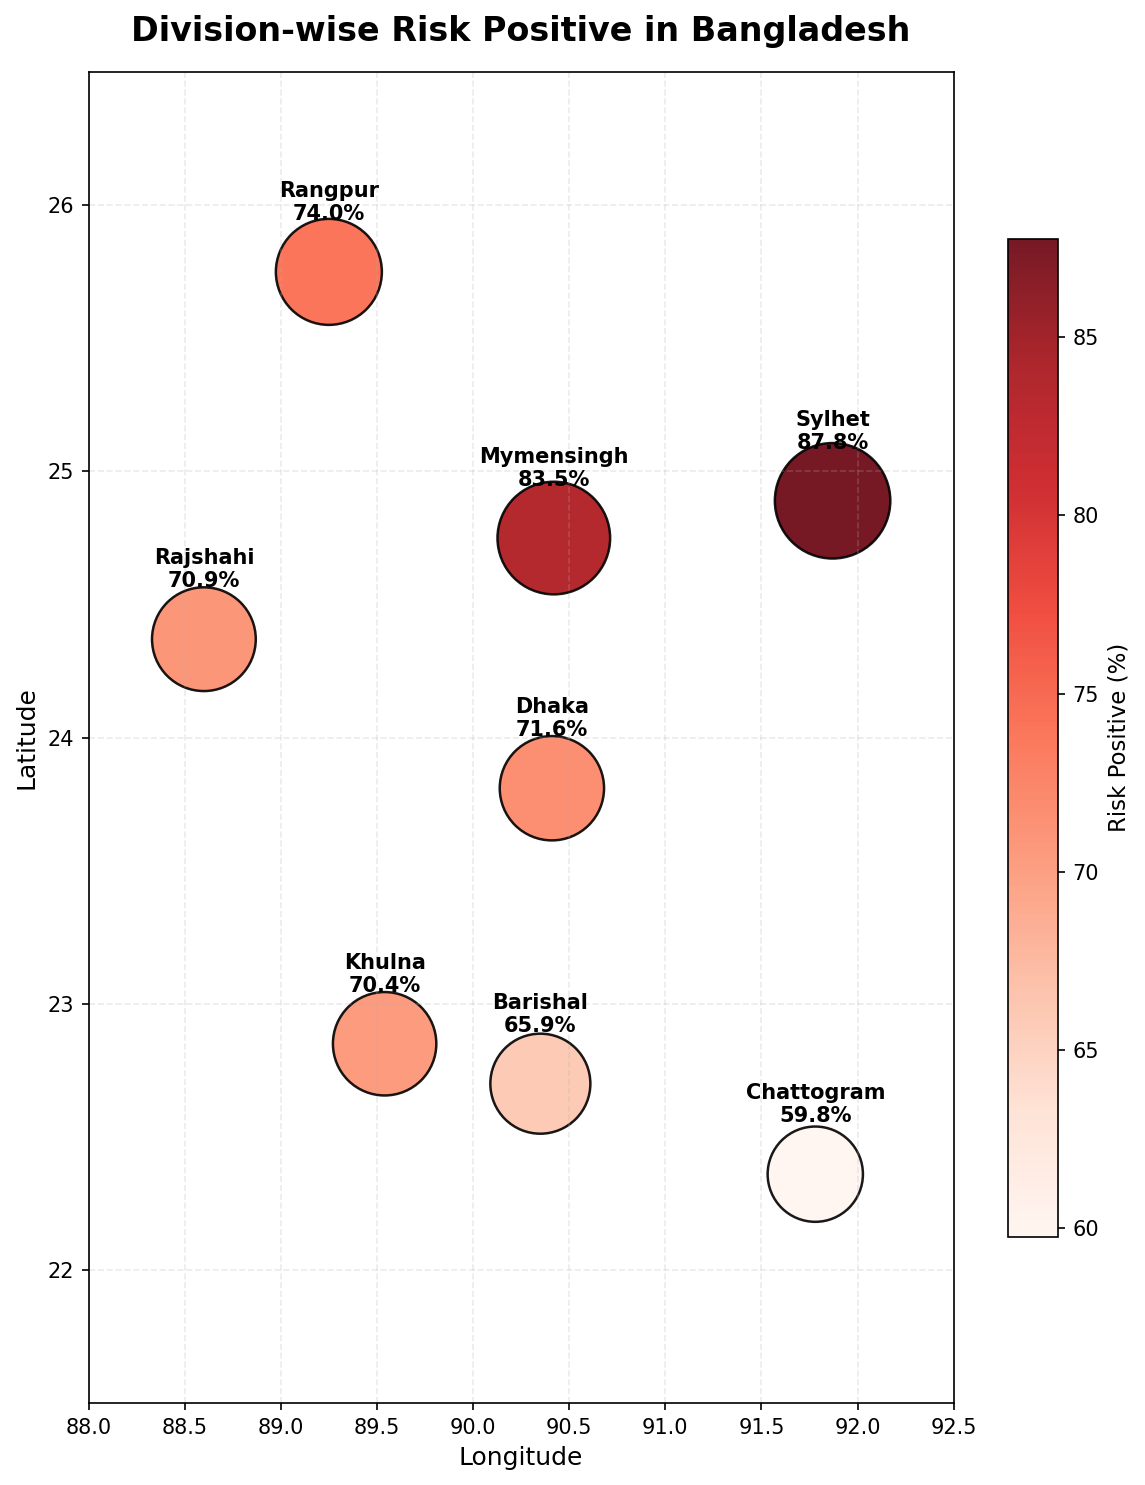

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. division-level suicidal risk summary
division_risk = (
    df_test.dropna(subset=['division_institute'])
    .groupby('division_institute')['suicidal_risk']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
).reset_index()

# 2. division center coordinates
division_coords_df = pd.DataFrame({
    'division_institute': ['Rangpur', 'Rajshahi', 'Mymensingh', 'Sylhet',
                           'Dhaka', 'Khulna', 'Barishal', 'Chattogram'],
    'lat': [25.75, 24.37, 24.75, 24.89, 23.81, 22.85, 22.70, 22.36],
    'lon': [89.25, 88.60, 90.42, 91.87, 90.41, 89.54, 90.35, 91.78]
})

# 3. merge
division_risk = division_risk.merge(division_coords_df, on='division_institute', how='left')

# 4. choose your positive-risk column name
positive_col = 'Risk Positive'   # change if needed

# 5. plot division-only map
fig, ax = plt.subplots(figsize=(8, 10), dpi=150)

sc = ax.scatter(
    division_risk['lon'],
    division_risk['lat'],
    s=division_risk[positive_col] * 35,
    c=division_risk[positive_col],
    cmap='Reds',
    edgecolor='black',
    linewidth=1.2,
    alpha=0.9
)

# labels
for _, row in division_risk.iterrows():
    ax.text(
        row['lon'],
        row['lat'] + 0.18,
        f"{row['division_institute']}\n{row[positive_col]:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# styling to resemble Bangladesh area
ax.set_xlim(88.0, 92.5)
ax.set_ylim(21.5, 26.5)
ax.set_title('Division-wise Risk Positive in Bangladesh', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(alpha=0.25, linestyle='--')

cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label('Risk Positive (%)', fontsize=11)

plt.tight_layout()
plt.show()

In [25]:
df_test.to_csv('/kaggle/working/StudentSafe_with_division.csv', index=False)

In [26]:
import os
os.listdir('/kaggle/working/')

['StudentSafe_with_division.csv', '__notebook__.ipynb']

In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zarif98sjs/bangladeshgeojson")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/zarif98sjs/bangladeshgeojson


In [28]:
import geopandas

gdf = geopandas.read_file('/kaggle/input/datasets/zarif98sjs/bangladeshgeojson/Bangladesh_GeoJSON/bangladesh_geojson_adm1_8_divisions_bibhags.json')

In [29]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Shape_Leng  8 non-null      float64       
 1   Shape_Area  8 non-null      float64       
 2   ADM1_EN     8 non-null      object        
 3   ADM1_PCODE  8 non-null      object        
 4   ADM1_REF    0 non-null      object        
 5   ADM1ALT1EN  0 non-null      object        
 6   ADM1ALT2EN  0 non-null      object        
 7   ADM0_EN     8 non-null      object        
 8   ADM0_PCODE  8 non-null      object        
 9   date        8 non-null      datetime64[ms]
 10  validOn     8 non-null      datetime64[ms]
 11  validTo     0 non-null      object        
 12  geometry    8 non-null      geometry      
dtypes: datetime64[ms](2), float64(2), geometry(1), object(8)
memory usage: 964.0+ bytes


In [30]:
gdf[['ADM1_EN', 'geometry']]

,ADM1_EN,geometry
0,Barisal,"MULTIPOLYGON (((90.47753 21.76919, 90.4764 21...."
1,Chittagong,"MULTIPOLYGON (((92.32719 20.63543, 92.32749 20..."
2,Dhaka,"MULTIPOLYGON (((90.45673 23.00396, 90.45631 23..."
3,Khulna,"MULTIPOLYGON (((89.24623 21.68914, 89.2484 21...."
4,Mymensingh,"POLYGON ((89.76844 25.43233, 89.76857 25.43221..."
5,Rajshahi,"POLYGON ((89.02818 25.27743, 89.02833 25.27742..."
6,Rangpur,"MULTIPOLYGON (((89.51742 26.0265, 89.51753 26...."
7,Sylhet,"MULTIPOLYGON (((91.30353 23.99673, 91.30344 23..."


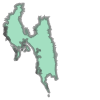

In [31]:
gdf['geometry'].to_list()[1]

Index(['division_institute', 'Risk Negative', 'Risk Positive'], dtype='object', name='suicidal_risk')
Index(['Shape_Leng', 'Shape_Area', 'ADM1_EN', 'ADM1_PCODE', 'ADM1_REF',
       'ADM1ALT1EN', 'ADM1ALT2EN', 'ADM0_EN', 'ADM0_PCODE', 'date', 'validOn',
       'validTo', 'geometry'],
      dtype='object')
   Shape_Leng  Shape_Area     ADM1_EN ADM1_PCODE ADM1_REF ADM1ALT1EN  \
0   25.424604    0.889395     Barisal       BD10     None       None   
1   30.287321    2.737796  Chittagong       BD20     None       None   
2   12.197758    1.806506       Dhaka       BD30     None       None   
3   38.409385    1.826575      Khulna       BD40     None       None   
4    8.166577    0.941812  Mymensingh       BD45     None       None   

  ADM1ALT2EN     ADM0_EN ADM0_PCODE       date    validOn validTo  \
0       None  Bangladesh         BD 2015-01-01 2020-11-13    None   
1       None  Bangladesh         BD 2015-01-01 2020-11-13    None   
2       None  Bangladesh         BD 2015-01-01 2020-11

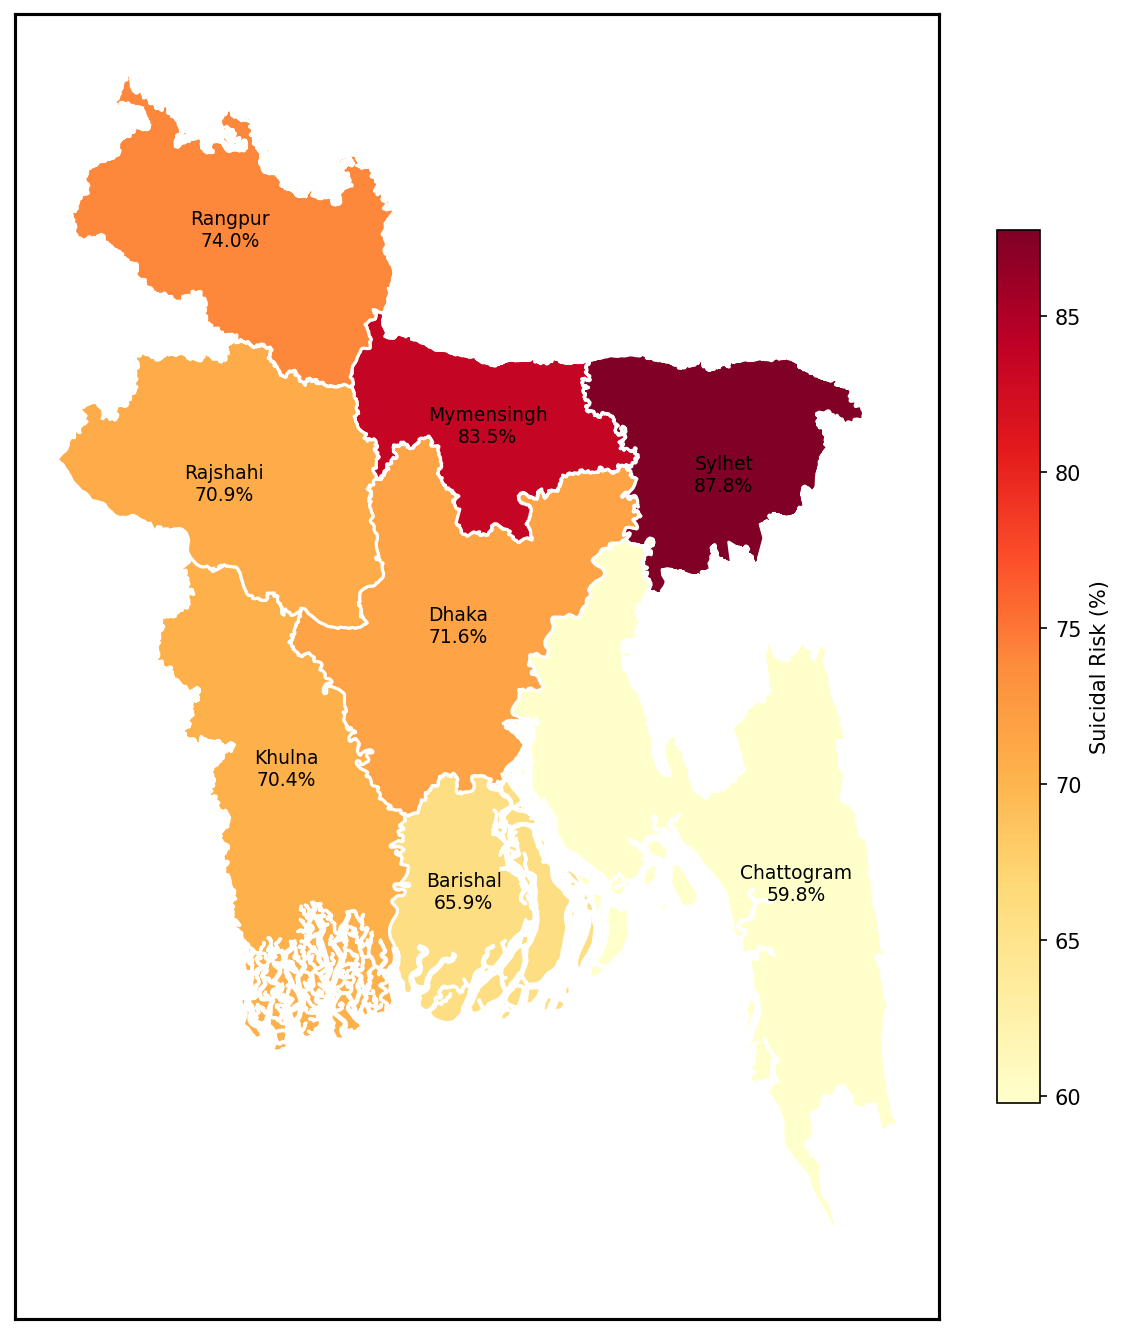

In [32]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Division-wise suicidal risk summary
division_risk = (
    df_test.dropna(subset=['division_institute'])
    .groupby('division_institute')['suicidal_risk']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
).reset_index()

# Check column names
print(division_risk.columns)

# Use the correct positive column name
positive_col = 'Risk Positive'   # change if needed

# 2. Read Bangladesh ADM1 divisions GeoJSON
gdf = gpd.read_file(
    '/kaggle/input/datasets/zarif98sjs/bangladeshgeojson/Bangladesh_GeoJSON/bangladesh_geojson_adm1_8_divisions_bibhags.json'
)

# 3. Check columns in map file
print(gdf.columns)
print(gdf.head())

# 4. Pick the division-name column from the geojson
# If needed, replace 'shapeName' with the correct column after checking above
gdf['division_institute'] = gdf['ADM1_EN'].replace({
    'Chittagong': 'Chattogram',
    'Barisal': 'Barishal'
})

# 5. Merge map with your risk data
map_df = gdf.merge(division_risk, on='division_institute', how='left')

# 6. Plot choropleth
fig, ax = plt.subplots(figsize=(8, 10), dpi=150)

map_df.plot(
    column=positive_col,
    cmap='YlOrRd',
    linewidth=1.5,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Suicidal Risk (%)',
        'orientation': 'vertical',
        'shrink': 0.6
    },
    ax=ax
)
# 7. Add division labels
for _, row in map_df.iterrows():
    pt = row.geometry.representative_point()
    ax.text(
        pt.x, pt.y,
        f"{row['division_institute']}\n{row[positive_col]:.1f}%",
        ha='center',
        va='center',
        fontsize=9,
        # fontweight='bold',
        color='black'
    )

# ax.set_title('Division-wise Students Suicidal Risk in Bangladesh', fontsize=16, fontweight='bold')
# 🔹 SHOW AXIS (to enable box)
ax.set_axis_on()

# 🔹 KEEP SAME LIMITS (important for layout)
ax.set_xlim(ax.get_xlim())
ax.set_ylim(ax.get_ylim())

# 🔹 MAKE BOX VISIBLE
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

# 🔹 REMOVE TICKS (optional, cleaner look)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

Index(['division_institute', 'Risk Negative', 'Risk Positive'], dtype='object', name='suicidal_risk')
Index(['Shape_Leng', 'Shape_Area', 'ADM1_EN', 'ADM1_PCODE', 'ADM1_REF',
       'ADM1ALT1EN', 'ADM1ALT2EN', 'ADM0_EN', 'ADM0_PCODE', 'date', 'validOn',
       'validTo', 'geometry'],
      dtype='object')
   Shape_Leng  Shape_Area     ADM1_EN ADM1_PCODE ADM1_REF ADM1ALT1EN  \
0   25.424604    0.889395     Barisal       BD10     None       None   
1   30.287321    2.737796  Chittagong       BD20     None       None   
2   12.197758    1.806506       Dhaka       BD30     None       None   
3   38.409385    1.826575      Khulna       BD40     None       None   
4    8.166577    0.941812  Mymensingh       BD45     None       None   

  ADM1ALT2EN     ADM0_EN ADM0_PCODE       date    validOn validTo  \
0       None  Bangladesh         BD 2015-01-01 2020-11-13    None   
1       None  Bangladesh         BD 2015-01-01 2020-11-13    None   
2       None  Bangladesh         BD 2015-01-01 2020-11

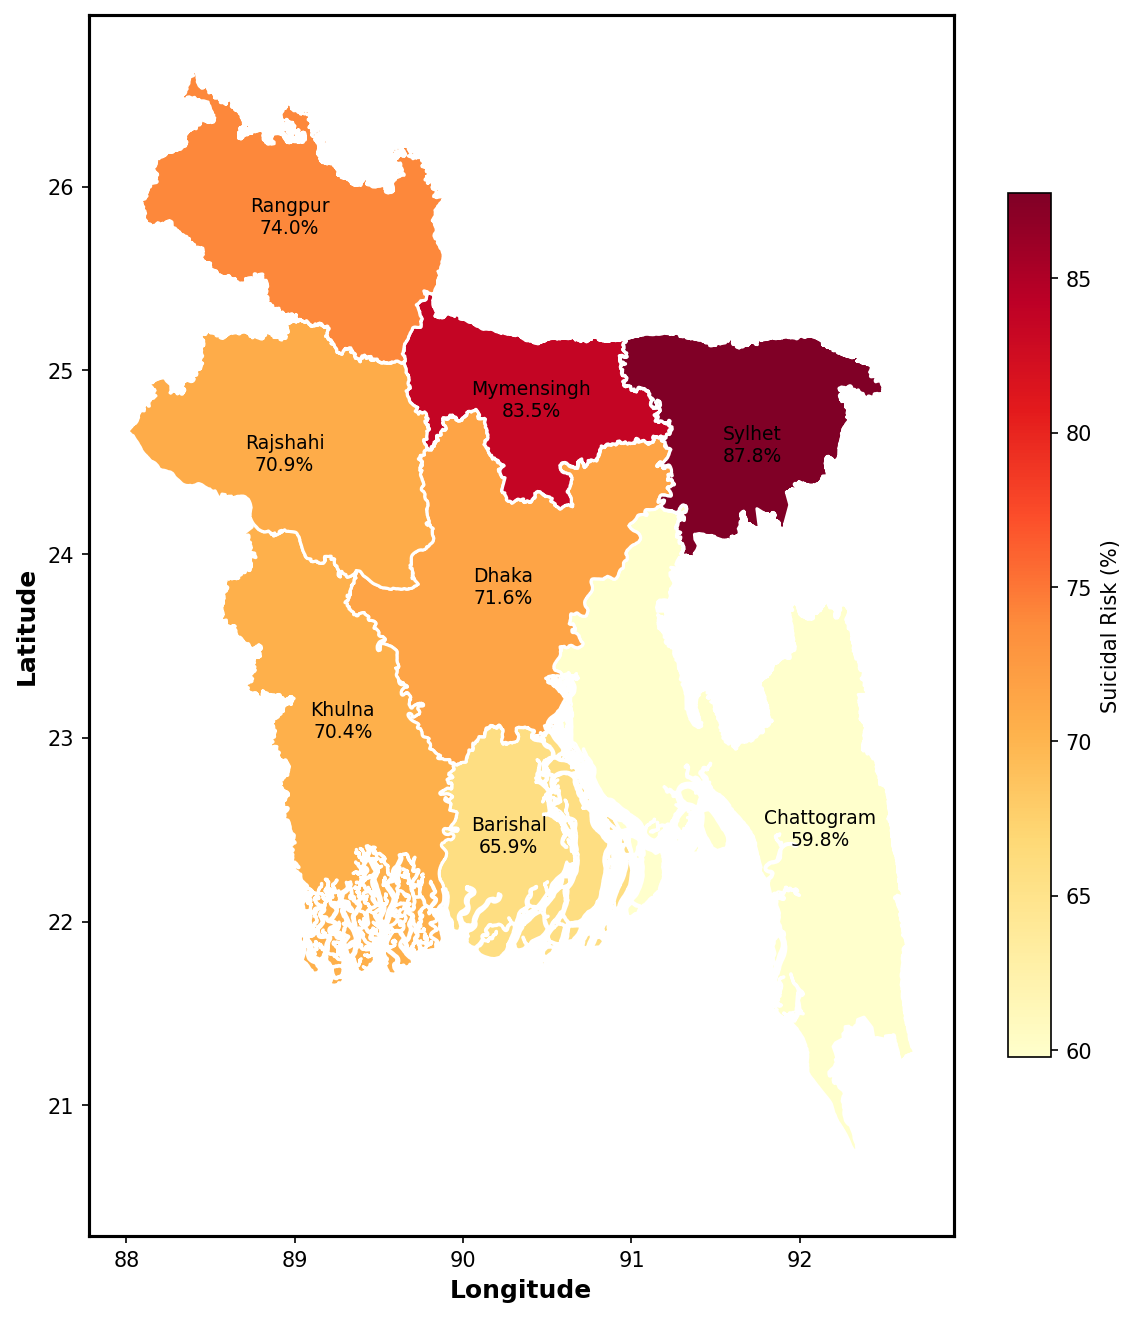

<Figure size 640x480 with 0 Axes>

In [33]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Division-wise suicidal risk summary
division_risk = (
    df_test.dropna(subset=['division_institute'])
    .groupby('division_institute')['suicidal_risk']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
).reset_index()

# Check column names
print(division_risk.columns)

# Use the correct positive column name
positive_col = 'Risk Positive'   # change if needed

# 2. Read Bangladesh ADM1 divisions GeoJSON
gdf = gpd.read_file(
    '/kaggle/input/datasets/zarif98sjs/bangladeshgeojson/Bangladesh_GeoJSON/bangladesh_geojson_adm1_8_divisions_bibhags.json'
)

# 3. Check columns in map file
print(gdf.columns)
print(gdf.head())

# 4. Pick the division-name column from the geojson
# If needed, replace 'shapeName' with the correct column after checking above
gdf['division_institute'] = gdf['ADM1_EN'].replace({
    'Chittagong': 'Chattogram',
    'Barisal': 'Barishal'
})

# 5. Merge map with your risk data
map_df = gdf.merge(division_risk, on='division_institute', how='left')

# 6. Plot choropleth
fig, ax = plt.subplots(figsize=(8, 10), dpi=150)

map_df.plot(
    column=positive_col,
    cmap='YlOrRd',
    linewidth=1.5,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Suicidal Risk (%)',
        'orientation': 'vertical',
        'shrink': 0.6
    },
    ax=ax
)
# 7. Add division labels
for _, row in map_df.iterrows():
    pt = row.geometry.representative_point()
    ax.text(
        pt.x, pt.y,
        f"{row['division_institute']}\n{row[positive_col]:.1f}%",
        ha='center',
        va='center',
        fontsize=9,
        # fontweight='bold',
        color='black'
    )

# ax.set_title('Division-wise Students Suicidal Risk in Bangladesh', fontsize=16, fontweight='bold')
# 🔹 SHOW AXIS (to enable box)
ax.set_axis_on()

# 🔹 KEEP SAME LIMITS (important for layout)
ax.set_xlim(ax.get_xlim())
ax.set_ylim(ax.get_ylim())

# 🔹 MAKE BOX VISIBLE
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

# 🔹 show axis + box
ax.set_axis_on()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

# 🔹 Axis labels
ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

  division_institute  survey_count  survey_percent
0           Barishal           293        8.369037
1         Chattogram           604       17.252214
2              Dhaka          1724       49.243073
3             Khulna           385       10.996858
4         Mymensingh            91        2.599257
5           Rajshahi           182        5.198515
6            Rangpur           173        4.941445
7             Sylhet            49        1.399600


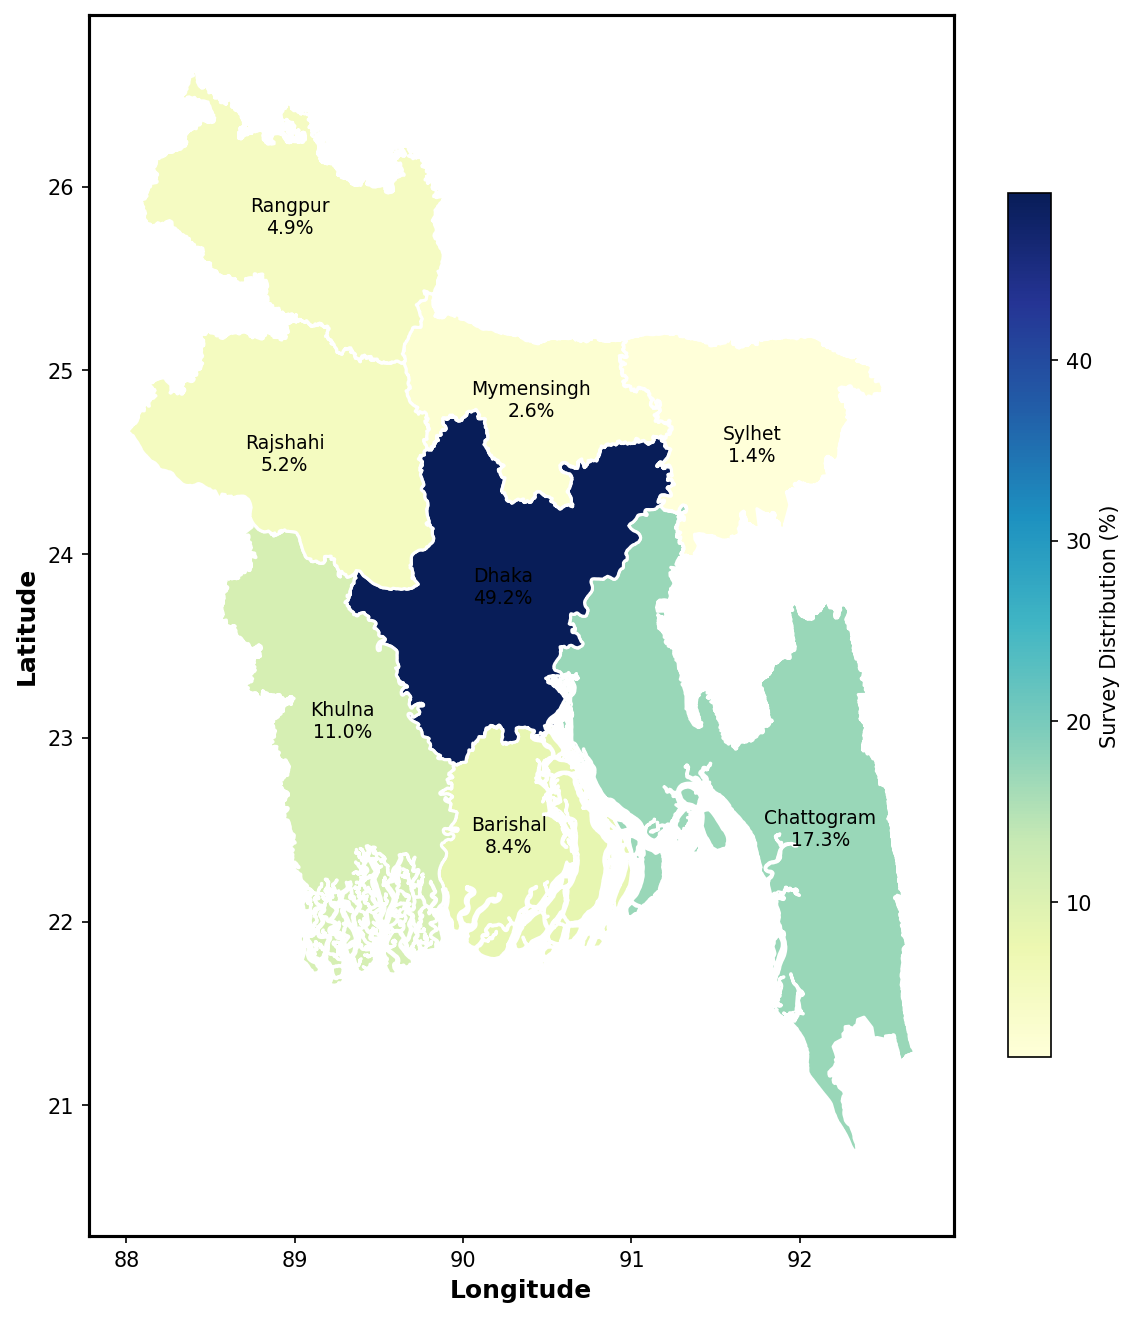

In [34]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Count total surveys in each division
division_counts = (
    df_test.dropna(subset=['division_institute'])
    .groupby('division_institute')
    .size()
    .reset_index(name='survey_count')
)

# 2. Convert counts to % of total survey
total_surveys = division_counts['survey_count'].sum()
division_counts['survey_percent'] = (division_counts['survey_count'] / total_surveys) * 100

print(division_counts)

# 3. Read Bangladesh divisions shapefile / geojson
gdf = gpd.read_file(
    '/kaggle/input/datasets/zarif98sjs/bangladeshgeojson/Bangladesh_GeoJSON/bangladesh_geojson_adm1_8_divisions_bibhags.json'
)

# 4. Match division names
gdf['division_institute'] = gdf['ADM1_EN'].replace({
    'Chittagong': 'Chattogram',
    'Barisal': 'Barishal'
})

# 5. Merge map with survey distribution data
map_df = gdf.merge(division_counts, on='division_institute', how='left')

# 6. Plot choropleth
fig, ax = plt.subplots(figsize=(8, 10), dpi=150)

map_df.plot(
    column='survey_percent',
    cmap='YlGnBu',
    linewidth=1.5,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Survey Distribution (%)',
        'orientation': 'vertical',
        'shrink': 0.6
    },
    ax=ax
)

# 7. Add labels
for _, row in map_df.iterrows():
    pt = row.geometry.representative_point()
    ax.text(
        pt.x, pt.y,
        f"{row['division_institute']}\n{row['survey_percent']:.1f}%",
        ha='center',
        va='center',
        fontsize=9,
        color='black'
    )

# 8. Axis and frame styling
ax.set_axis_on()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

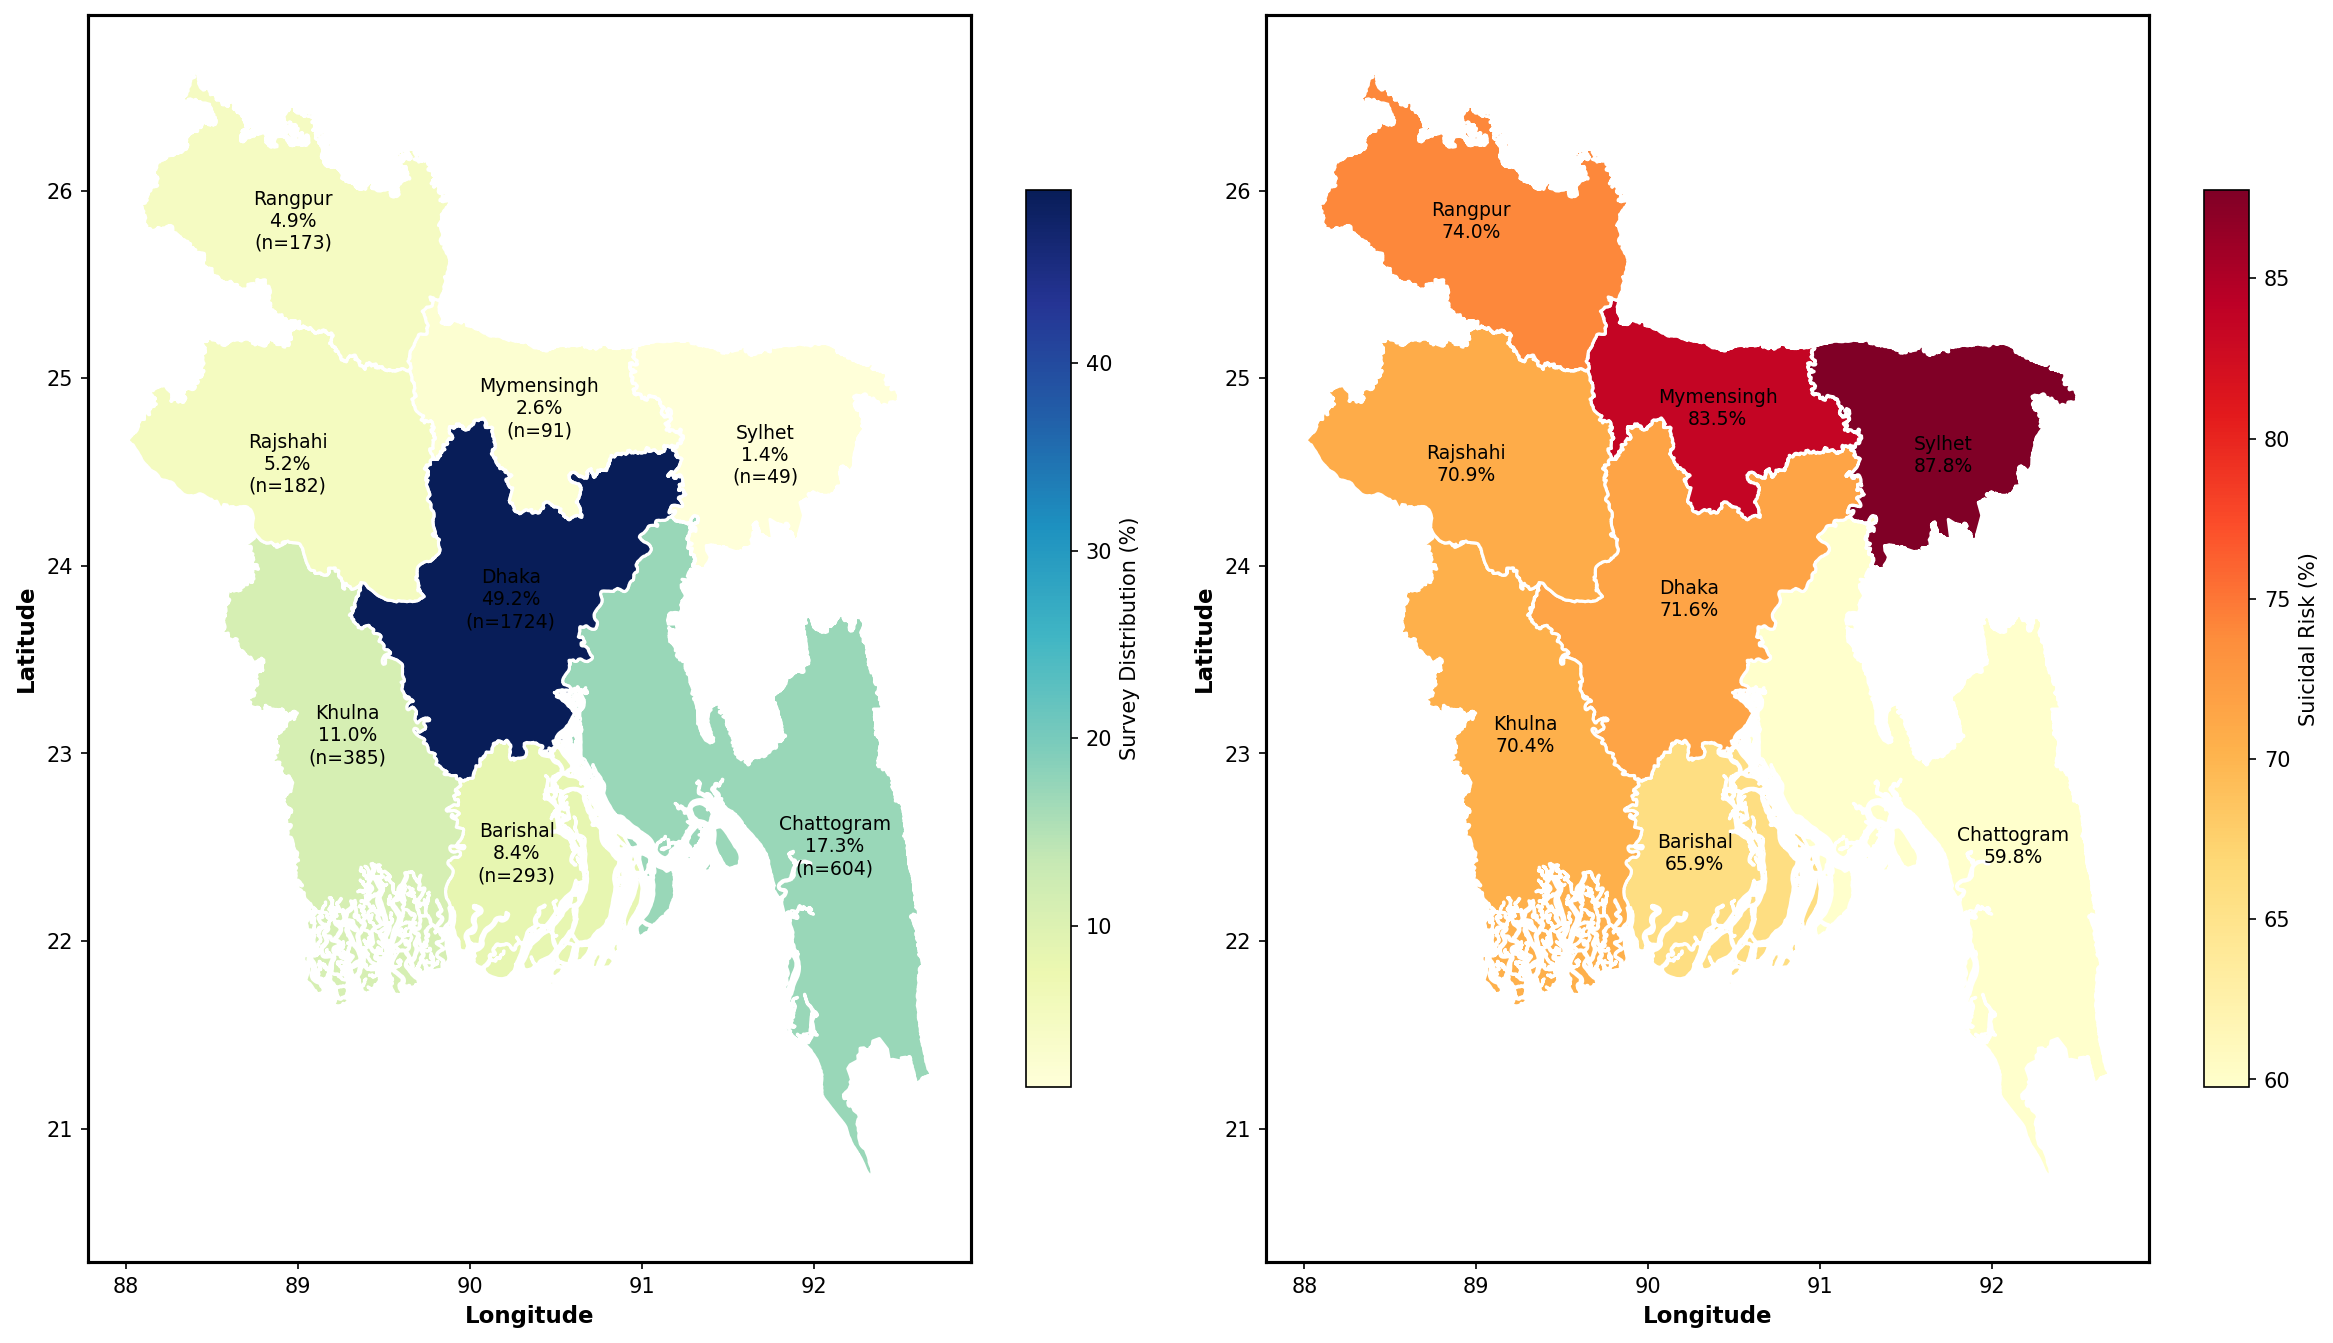

In [35]:
map_risk = gdf.merge(division_risk, on='division_institute', how='left') 
map_survey = gdf.merge(division_counts, on='division_institute', how='left')

# ---------- Plot side by side ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 9), dpi=150)

# Map 1: Survey distribution % (NOW FIRST)
map_survey.plot(
    column='survey_percent',
    cmap='YlGnBu',
    linewidth=1.5,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Survey Distribution (%)',
        'orientation': 'vertical',
        'shrink': 0.7
    },
    ax=axes[0]
)

for _, row in map_survey.iterrows():
    pt = row.geometry.representative_point()
    axes[0].text(
        pt.x, pt.y,
        f"{row['division_institute']}\n{row['survey_percent']:.1f}%\n(n={row['survey_count']})",
        ha='center',
        va='center',
        fontsize=9,
        color='black'
    )

# axes[0].set_title('Division-wise Survey Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Latitude', fontsize=11, fontweight='bold')


# Map 2: Risk-positive % (NOW SECOND)
map_risk.plot(
    column=positive_col,
    cmap='YlOrRd',
    linewidth=1.5,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Suicidal Risk (%)',
        'orientation': 'vertical',
        'shrink': 0.7
    },
    ax=axes[1]
)

for _, row in map_risk.iterrows():
    pt = row.geometry.representative_point()
    axes[1].text(
        pt.x, pt.y,
        f"{row['division_institute']}\n{row[positive_col]:.1f}%",
        ha='center',
        va='center',
        fontsize=9,
        color='black'
    )

# axes[1].set_title('Division-wise Suicidal Risk Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Latitude', fontsize=11, fontweight='bold')


# Frame styling
for ax in axes:
    ax.set_axis_on()
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color('black')

plt.tight_layout()
plt.show()

Figure above presents the regional distribution of survey samples alongside the corresponding prevalence of suicidal risk across Bangladesh. The survey distribution map indicates a strong sampling concentration in Dhaka, while several divisions such as Sylhet and Mymensingh have comparatively lower representation. Despite this imbalance, the risk map reveals higher suicidal risk proportions in Sylhet and Mymensingh, suggesting that elevated risk in these regions is not solely driven by sample size but reflects meaningful regional variation. These paired visualizations highlight the importance of interpreting risk estimates in the context of underlying sample distribution.